In [26]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np
import math


In [45]:
def get_sorted(dic):
    return [dic[k] for k in list(map(str,sorted(list(map(int, dic.keys())))))]

def get_betas(folder):
    betas = {}
    pattern = re.compile(r"Beta \s=\s(?P<value>[0-9]*\.[0-9]*)")
    for run in [f for f in next(os.walk(folder))[1]]:
        n_run = run.split('_')[-1]
        with open(os.path.join(folder,run,'out.txt')) as f:
            txt = f.read()
            match  = pattern.search(txt)
            if match is not None:
                betas[n_run] = match.group('value')
    return get_sorted(betas)

def get_cross_correlation(folder):
    corr = {}
    pattern = re.compile(r"\bLatent Dimension 0 \s*[Na0-9\.\-]+\s*(?P<value>[Na0-9\.\-]+)")
    for run in [f for f in next(os.walk(folder))[1]]:
        n_run = run.split('_')[-1]
        with open(os.path.join(folder,run,'out.txt')) as f:
            txt = f.read()
            match = pattern.findall(txt)[-1]
            if match is not None:
                if match == 'Nan':
                    corr[n_run] = float('nan')
                else:
                    corr[n_run] = float(match)
    return get_sorted(corr)

def get_labels_cross_correlation(folder):
    corr = {}
    pattern = re.compile(r"\bLatent Dimension 0 \s*[Na0-9\.\-]+\s*[Na0-9\.\-]+\s*(?P<value_a>[Na0-9\.\-]+)+\s*(?P<value_b>[Na0-9\.\-]+)[\r\n|\r|\n]Latent Dimension 1 \s*[Na0-9\.\-]+\s*[Na0-9\.\-]+\s*(?P<value_c>[Na0-9\.\-]+)+\s*(?P<value_d>[Na0-9\.\-]+)")
    for run in [f for f in next(os.walk(folder))[1]]:
        n_run = run.split('_')[-1]
        with open(os.path.join(folder,run,'out.txt')) as f:
            txt = f.read()
            match = pattern.findall(txt)[-1]
            if match is not None:
                match = [float(val) if val != 'Nan' else float('nan') for val in match ]
                corr[n_run] = match
    return get_sorted(corr)


[-0.226899,
 -0.254171,
 -0.257402,
 -0.312415,
 -0.176825,
 -0.16493,
 0.262785,
 -0.092583,
 -0.14344,
 0.22815,
 -0.439539,
 -0.380488,
 0.398795,
 0.947743,
 0.667053,
 -0.215767,
 0.40503,
 -0.582453]

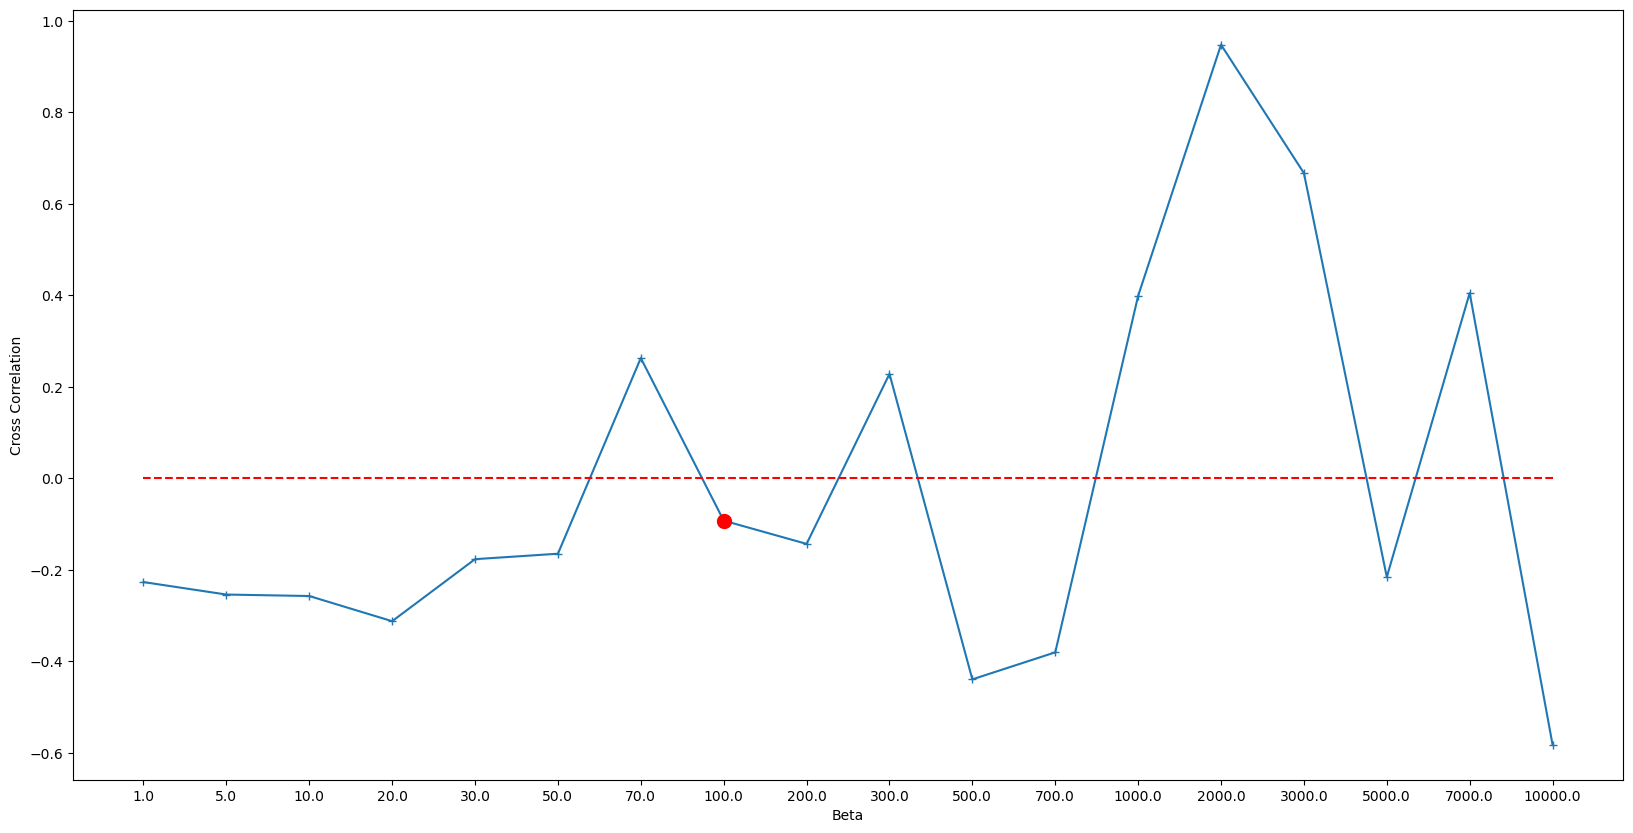

In [69]:
plt.rcParams["figure.figsize"] = (20,10)
folder = os.path.join(os.getcwd() +'/beta_search_500_elbo')
correlations = get_cross_correlation(folder)
betas = get_betas(folder)
plt.plot(betas,correlations, '+-')
minarg = np.argmin(np.abs([f if not math.isnan(f) else 1 for f in correlations]))
plt.plot(betas[minarg],correlations[minarg], 'ro', markersize=10)
plt.plot(betas,[0] * len(betas),'--', color='red')
plt.xlabel('Beta')
plt.ylabel('Cross Correlation')
correlations

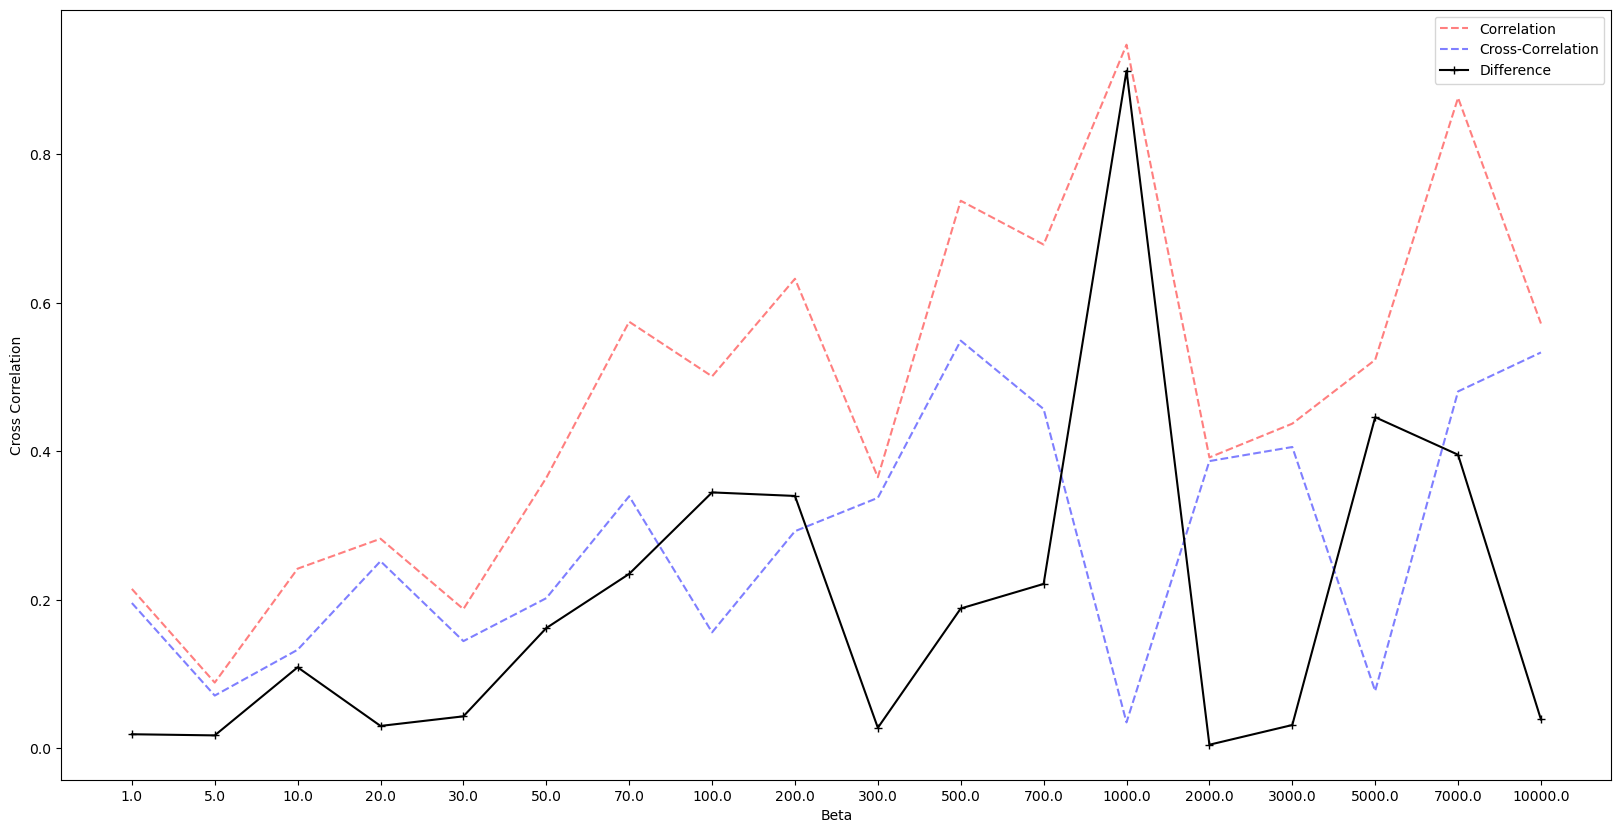

In [70]:
plt.close()
plt.rcParams["figure.figsize"] = (20,10)
labels_correlations = get_labels_cross_correlation(folder)
corr = []
cross = []
for values in labels_correlations:
    if True in [math.isnan(val) for val in values]:
        corr.append(float('nan'))
        cross.append(float('nan'))
    else:
        v1 = abs(values[0])+abs(values[3])
        v2 = abs(values[1])+abs(values[2])
        corr.append(max(v1,v2))
        cross.append(min(v1,v2))
diff  = [x-y for x,y in zip(corr,cross)]
plt.plot(betas,corr, 'r--', label='Correlation', alpha=0.5)
plt.plot(betas,cross, 'b--', label='Cross-Correlation', alpha=0.5)
plt.plot(betas,diff, '+-', color='black', label='Difference')
plt.xlabel('Beta')
plt.ylabel('Cross Correlation')
plt.legend()